# ek_baseline_zscore
Causal rolling Z-score per channel · top-p% aggregation · event F0.5 threshold tuning

In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from sentinel.ml_logic.metrics import compute_all_metrics, event_f05
from sentinel.ml_logic.thresholds import tune_threshold

In [2]:
# ── config ───────────────────────────────────────────────────────────────────
CHANNELS = [
    'channel_41', 'channel_42', 'channel_43',
    'channel_44', 'channel_45', 'channel_46',
]
TRAIN_FRAC     = 0.70
VAL_FRAC       = 0.15
# internal TEST: remaining 15% — frozen, not used for threshold tuning
ROLLING_WINDOW = 100     # causal rolling window (≈ small sinusoid period)
P_GRID         = [0.17, 0.33, 0.5, 0.67, 1.0]  # top-p fractions to try

ANOMALY_COLOR = '#e74c3c'
NOMINAL_COLOR = '#2980b9'

RAW_DIR  = Path('../data/raw')
SUB_DIR  = Path('../submissions')
SUB_DIR.mkdir(exist_ok=True)

In [3]:
cols  = ['id', 'is_anomaly'] + CHANNELS
train = pq.read_table(str(RAW_DIR / 'train.parquet'), columns=cols
                      ).to_pandas().set_index('id')
test  = pq.read_table(str(RAW_DIR / 'test.parquet'),
                      columns=['id'] + CHANNELS).to_pandas().set_index('id')
print(f'Train: {len(train):,} rows  |  Test: {len(test):,} rows')

Train: 14,728,321 rows  |  Test: 521,280 rows


In [4]:
n       = len(train)
tr_end  = int(n * TRAIN_FRAC)
val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

X_tr       = train[CHANNELS].iloc[:tr_end]
X_val      = train[CHANNELS].iloc[tr_end:val_end]
X_test_int = train[CHANNELS].iloc[val_end:]
y_tr       = train['is_anomaly'].values[:tr_end]
y_val      = train['is_anomaly'].values[tr_end:val_end]
y_test_int = train['is_anomaly'].values[val_end:]
print(f'Train: {len(X_tr):,} | Val: {len(X_val):,} | Test_int: {len(X_test_int):,}')
print(f'Val rate: {y_val.mean():.4%}  | Test_int rate: {y_test_int.mean():.4%}')

Train: 10,309,824 | Val: 2,209,248 | Test_int: 2,209,249
Val rate: 10.1136%  | Test_int rate: 10.7724%


## [Optional] Frequency decomposition
Пропустить → пайплайн работает с оригинальными 6 каналами.  
Выполнить → `CHANNELS`, `X_tr / X_val / X_test_int` заменяются на подканалы из `SUBCHANNEL_PARTS`.  
Все последующие ячейки (rolling z-score, grid search, global comparison, submission) подхватывают изменение автоматически.

In [ ]:
from scipy.ndimage import uniform_filter1d
import json

# ── config ────────────────────────────────────────────────────────────────────
SUBCHANNEL_PARTS  = ['res']   # любое подмножество: 'sin1'  'sin2'  'sin3'  'res'
BIG_WINDOW_DECOMP = 50_000   # окно большой синусоиды (из ek_freq_eda)
# ─────────────────────────────────────────────────────────────────────────────

freq_map = json.loads(Path('../data/freq_map.json').read_text())

def _decompose(arr, bw, mw, sw):
    """Three-level cascade decomposition → (sin1, sin2, sin3, residual)."""
    a    = np.asarray(arr, dtype=np.float64)
    sin1 = uniform_filter1d(a,             size=bw, mode='nearest')
    r1   = a - sin1
    s2r  = uniform_filter1d(r1,            size=mw, mode='nearest')
    s3r  = uniform_filter1d(r1 - s2r,     size=sw, mode='nearest')
    sin2 = uniform_filter1d(r1 - s3r,     size=mw, mode='nearest')
    r2   = r1 - sin2
    sin3 = uniform_filter1d(r2,            size=sw, mode='nearest')
    res  = r2 - sin3
    return sin1, sin2, sin3, res

_base_ch   = [c for c in CHANNELS if not c.endswith(('_sin1','_sin2','_sin3','_res'))]
_part_keys = ['sin1', 'sin2', 'sin3', 'res']

for df, label in [(train, 'train'), (test, 'test')]:
    print(f'Decomposing {label} ({len(df):,} rows) …')
    for ch in _base_ch:
        T1, T2 = freq_map[ch]
        mw = max(T1 * 2, T2 // 3)
        sw = max(3, T1 // 5)
        parts = _decompose(df[ch].values, BIG_WINDOW_DECOMP, mw, sw)
        for name, arr in zip(_part_keys, parts):
            df[f'{ch}_{name}'] = arr
        print(f'  {ch}: T1={T1}  T2={T2}  sw={sw}  mw={mw}  bw={BIG_WINDOW_DECOMP:,}')

CHANNELS   = [f'{ch}_{p}' for ch in _base_ch for p in SUBCHANNEL_PARTS]
X_tr       = train[CHANNELS].iloc[:tr_end]
X_val      = train[CHANNELS].iloc[tr_end:val_end]
X_test_int = train[CHANNELS].iloc[val_end:]

print(f'\nCHANNELS ({len(CHANNELS)}): {CHANNELS}')

In [5]:
def rolling_zscore_df(df, window):
    """Causal per-channel rolling Z-score (backward-looking)."""
    roll = df.rolling(window=window, min_periods=max(2, window // 10))
    mu   = roll.mean()
    sd   = roll.std().fillna(1.0).clip(lower=1e-8)
    return ((df - mu) / sd).fillna(0.0)


def top_p_mean(z_arr, p):
    """Mean of top-p fraction of channels by abs Z-score. Vectorised."""
    n_top = max(1, int(z_arr.shape[1] * p))
    z_abs = np.abs(z_arr)
    top   = np.partition(z_abs, -n_top, axis=1)[:, -n_top:]
    return top.mean(axis=1)

In [ ]:
ROLLING_WINDOW = 1000
print(f'Computing rolling Z-score (window={ROLLING_WINDOW:,}) on {len(train):,} rows …')
z_full     = rolling_zscore_df(train[CHANNELS], ROLLING_WINDOW)
z_tr       = z_full.iloc[:tr_end]
z_val      = z_full.iloc[tr_end:val_end]
z_test_int = z_full.iloc[val_end:]
print('Done.')

Computing rolling Z-score (window=1,000) on 14,728,321 rows …


In [ ]:
# Grid search: for each p, tune threshold and record best event F0.5
print(f'{"p":>6}  {"F0.5":>7}  {"thr":>10}')
print('-' * 30)

best_score, best_p, best_thr, best_result = -1, None, None, None

for p in P_GRID:
    scores_val = top_p_mean(z_val.values, p=p)
    res = tune_threshold(scores_val, y_val, metric_fn=event_f05,
                         lo_percentile=(0, 90),
                         hi_percentile=(1, 99.99), n_sweep=120)
    print(f'{p:>6.2f}  {res["score"]:>7.4f}  {res["threshold"]:>10.4g}')
    if res['score'] > best_score:
        best_score, best_p, best_thr, best_result = (
            res['score'], p, res['threshold'], res)

print(f'\nBest  p={best_p}  threshold={best_thr:.4g}  F0.5={best_score:.4f}')

     p     F0.5         thr
------------------------------
  0.17   0.6000       4.947
  0.33   0.6000       4.947
  0.50   0.6034       2.983
  0.67   0.6034       2.667
  1.00   0.6481       2.293

Best  p=1.0  threshold=2.293  F0.5=0.6481


In [ ]:
scores_val = top_p_mean(z_val.values, p=best_p)
y_pred_val = (scores_val > best_thr).astype(np.int8)

metrics = compute_all_metrics(y_val, y_pred_val)
print('\n── Validation metrics ─────────────────────────────')
for k, v in metrics.items():
    print(f'  {k:<28} {v}')


── Validation metrics ─────────────────────────────
  event_f05                    0.648148
  event_f1                     0.424242
  event_f2                     0.315315
  event_precision              1.0
  event_recall                 0.269231
  esa_f05                      0.648148
  esa_precision                1.0
  esa_recall                   0.269231
  esa_tnr                      1.0
  event_detection_rate         0.269231
  tp_events                    7
  n_events                     26
  fp_pred_events               0
  pa_f1                        0.429463
  pa_precision                 1.0
  pa_recall                    0.27345
  row_precision                1.0
  row_recall                   0.00085
  row_f1                       0.001699


In [ ]:
# ── Internal test — threshold FROZEN from val tuning (no re-tuning) ───────────
scores_test_int_arr = top_p_mean(z_test_int.values, p=best_p)
y_pred_test_int     = (scores_test_int_arr > best_thr).astype(np.int8)

metrics_test_int = compute_all_metrics(y_test_int, y_pred_test_int)
print('── Internal test metrics ─────────────────────────')
for k, v in metrics_test_int.items():
    print(f'  {k:<28} {v}')

── Internal test metrics ─────────────────────────
  event_f05                    0.6875
  event_f1                     0.536585
  event_f2                     0.44
  event_precision              0.846154
  event_recall                 0.392857
  esa_f05                      0.6875
  esa_precision                0.846153
  esa_recall                   0.392857
  esa_tnr                      0.999999
  event_detection_rate         0.392857
  tp_events                    11
  n_events                     28
  fp_pred_events               2
  pa_f1                        0.440695
  pa_precision                 0.99997
  pa_recall                    0.282625
  row_precision                0.942857
  row_recall                   0.000139
  row_f1                       0.000277


## Global Z-score comparison
Фиксированная нормировка (μ, σ от X_tr) + тот же `top_p_mean` + тот же `tune_threshold`.  
Изолирует эффект **локального окна** от агрегации и тюнинга порога.  
Если F0.5 ≈ квантильному baseline → разница была именно в нормировке.  
Если F0.5 ≈ rolling → локальное окно бесполезно.

In [ ]:
%%script true
# Фиксированная нормировка на статистиках X_tr
mu_tr = X_tr.mean()
sd_tr = X_tr.std().clip(lower=1e-8)

z_val_global      = (X_val      - mu_tr) / sd_tr
z_test_int_global = (X_test_int - mu_tr) / sd_tr

# Grid search — тот же P_GRID, тот же tune_threshold
print(f'{"p":>6}  {"F0.5":>7}  {"thr":>10}')
print('-' * 30)

best_score_g, best_p_g, best_thr_g = -1, None, None

for p in P_GRID:
    scores_val_g = top_p_mean(z_val_global.values, p=p)
    res = tune_threshold(scores_val_g, y_val, metric_fn=event_f05, 
                         lo_percentile=(0, 90.0),
                         hi_percentile=(1, 99.9), n_sweep=120)
    print(f'{p:>6.2f}  {res["score"]:>7.4f}  {res["threshold"]:>10.4g}')
    if res['score'] > best_score_g:
        best_score_g, best_p_g, best_thr_g = res['score'], p, res['threshold']

print(f'\nBest  p={best_p_g}  threshold={best_thr_g:.4g}  F0.5={best_score_g:.4f}')

# Val metrics
scores_val_g_best = top_p_mean(z_val_global.values, p=best_p_g)
y_pred_val_g      = (scores_val_g_best > best_thr_g).astype(np.int8)
metrics_val_g     = compute_all_metrics(y_val, y_pred_val_g)

# Test_int metrics (порог заморожен)
scores_test_int_g = top_p_mean(z_test_int_global.values, p=best_p_g)
y_pred_test_int_g = (scores_test_int_g > best_thr_g).astype(np.int8)
metrics_test_g    = compute_all_metrics(y_test_int, y_pred_test_int_g)

# Сравнительная таблица
KEY_METRICS = ['event_f05', 'event_precision', 'event_recall',
               'fp_pred_events', 'event_detection_rate']
print(f'\n{"metric":<24}  {"rolling":>10}  {"global":>10}')
print('-' * 48)
for k in KEY_METRICS:
    rv = metrics[k]          # rolling (вычислен выше)
    gv = metrics_val_g[k]
    print(f'{k:<24}  {rv:>10}  {gv:>10}')

In [ ]:
from sentinel.ml_logic.data import find_anomaly_segments

def split_tp_fn(y_true, y_pred):
    true_segs = find_anomaly_segments(y_true)
    pred_segs = find_anomaly_segments(y_pred)
    tp, fn = [], []
    for ts in true_segs:
        hit = any(ps['end'] >= ts['start'] and ps['start'] <= ts['end']
                  for ps in pred_segs)
        (tp if hit else fn).append(ts)
    return tp, fn


def plot_score_timeline(scores, y_true, thr, tp_events, fn_events, title=''):
    """Score over time with TP/FN event spans. Subsampled for speed."""
    step = max(1, len(scores) // 50_000)
    idx  = np.arange(0, len(scores), step)
    fig, ax = plt.subplots(figsize=(18, 3))
    ax.plot(idx, scores[idx], lw=0.4, color=NOMINAL_COLOR, label='anomaly score')
    ax.axhline(thr, color='black', lw=1.2, ls='--', label=f'threshold {thr:.4g}')
    for ev in tp_events:
        ax.axvspan(ev['start'], ev['end'], color='green', alpha=0.25, linewidth=0)
    for ev in fn_events:
        ax.axvspan(ev['start'], ev['end'], color=ANOMALY_COLOR, alpha=0.35, linewidth=0)
    from matplotlib.patches import Patch
    ax.legend(handles=[
        ax.lines[0], ax.lines[1],
        Patch(color='green', alpha=0.4, label=f'TP events ({len(tp_events)})'),
        Patch(color=ANOMALY_COLOR, alpha=0.4, label=f'FN events ({len(fn_events)})'),
    ], fontsize=8, loc='upper right')
    ax.set_xlabel('Val row index'); ax.set_ylabel('Score')
    ax.set_title(title or 'Score timeline')
    plt.tight_layout(); plt.show()


def plot_score_dist(scores, y_true, thr):
    """Score histogram: nominal vs anomaly."""
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(scores[y_true == 0], bins=300, density=True,
            color=NOMINAL_COLOR, alpha=0.6, label='nominal')
    ax.hist(scores[y_true == 1], bins=80, density=True,
            color=ANOMALY_COLOR, alpha=0.7, label='anomaly')
    ax.axvline(thr, color='black', ls='--', lw=1.2, label=f'threshold {thr:.4g}')
    ax.set_xlabel('Score'); ax.set_ylabel('Density')
    ax.set_title('Score distribution: nominal vs anomaly')
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()


def plot_duration_hist(tp_events, fn_events):
    """Event duration distribution: TP (caught) vs FN (missed)."""
    tp_len = [e['length'] for e in tp_events]
    fn_len = [e['length'] for e in fn_events]
    bins   = np.logspace(0, 6, 50)
    fig, axes = plt.subplots(1, 2, figsize=(13, 3), sharey=True)
    for ax, lens, color, label in [
        (axes[0], tp_len, 'green',     f'TP — caught ({len(tp_len)})'),
        (axes[1], fn_len, ANOMALY_COLOR, f'FN — missed ({len(fn_len)})'),
    ]:
        if lens:
            ax.hist(lens, bins=bins, color=color, alpha=0.75)
        ax.set_xscale('log'); ax.set_xlabel('Event length (rows)')
        ax.set_ylabel('Count'); ax.set_title(label)
    plt.suptitle('Event duration distribution (log scale)', y=1.02)
    plt.tight_layout(); plt.show()

    if tp_len and fn_len:
        print(f'TP median length: {int(np.median(tp_len)):,}  '
              f'| FN median length: {int(np.median(fn_len)):,}')


def plot_missed_zoom(fn_events, scores, y_true, X_val_df, channels, thr,
                     n_show=3, margin=500):
    """Zoom on up to n_show missed events: raw channels + score."""
    show = fn_events[:n_show]
    if not show:
        print('No missed events to display.'); return
    fig, axes = plt.subplots(len(show), 1, figsize=(15, 4.5 * len(show)),
                             squeeze=False)
    for ax_row, ev in zip(axes, show):
        ax = ax_row[0]
        s  = max(0, ev['start'] - margin)
        e  = min(len(scores) - 1, ev['end'] + margin)
        xs = np.arange(s, e + 1)
        for ch in channels:
            ax.plot(xs, X_val_df[ch].values[s: e + 1], lw=0.5, alpha=0.7, label=ch)
        ax.axvspan(ev['start'], ev['end'], color=ANOMALY_COLOR, alpha=0.25, linewidth=0)
        ax2 = ax.twinx()
        ax2.plot(xs, scores[s: e + 1], color='orange', lw=0.9, alpha=0.8, label='score')
        ax2.axhline(thr, color='black', ls='--', lw=1, alpha=0.7)
        ax2.set_ylabel('Score', color='orange')
        ax.set_title(f"Missed event  start={ev['start']:,}  "
                     f"end={ev['end']:,}  len={ev['length']:,}")
        ax.legend(fontsize=7, loc='upper left', ncol=len(channels))
    plt.tight_layout(); plt.show()

## Viz 1 — Score timeline

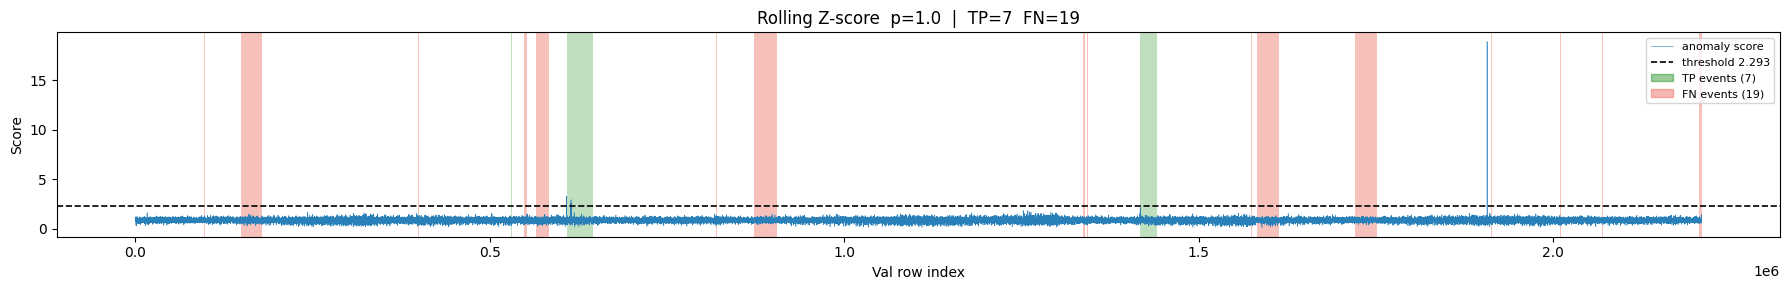

In [ ]:
tp_events, fn_events = split_tp_fn(y_val, y_pred_val)
plot_score_timeline(
    scores_val, y_val, best_thr, tp_events, fn_events,
    title=f'Rolling Z-score  p={best_p}  |  '
          f'TP={len(tp_events)}  FN={len(fn_events)}')

## Viz 2 — Score distribution

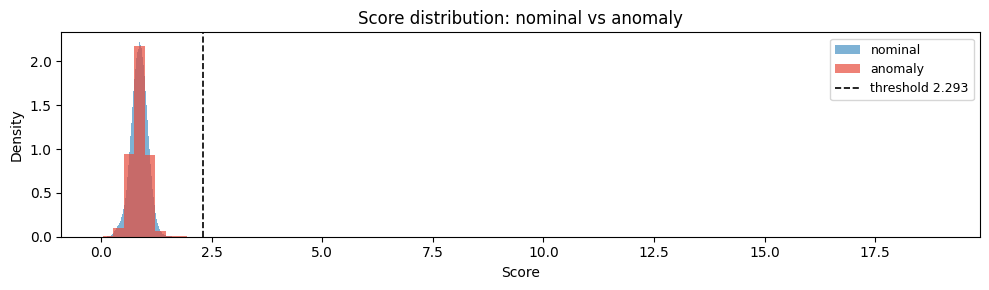

In [ ]:
plot_score_dist(scores_val, y_val, best_thr)

## Viz 3 — Event duration: TP vs FN

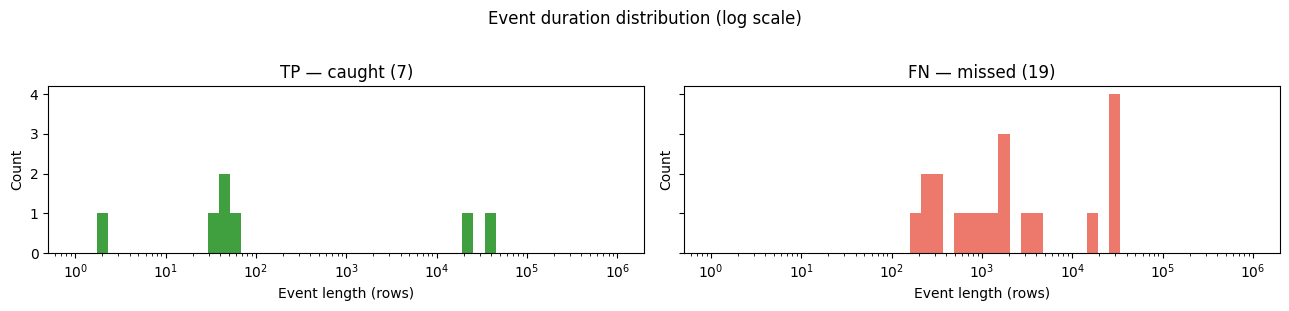

TP median length: 51  | FN median length: 1,755


In [ ]:
plot_duration_hist(tp_events, fn_events)

## Viz 4 — Zoom on missed events

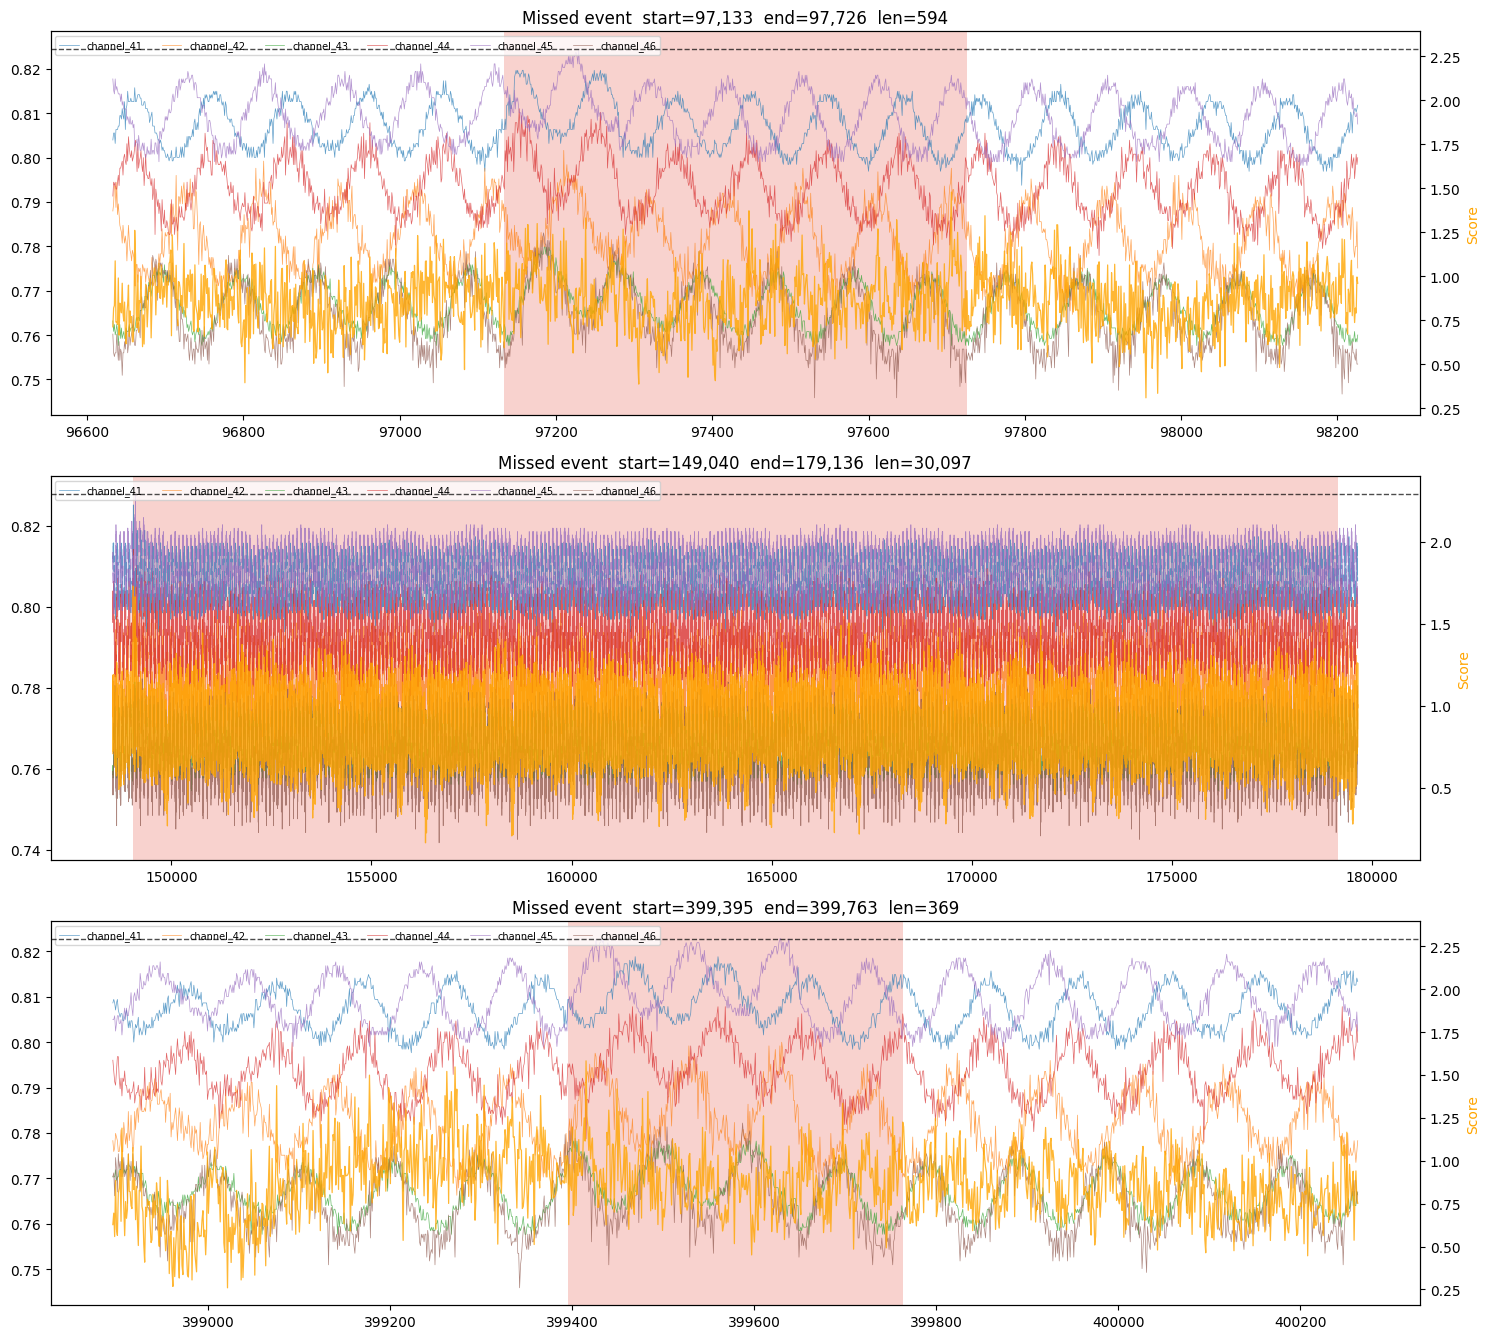

In [ ]:
plot_missed_zoom(fn_events, scores_val, y_val, X_val, CHANNELS, best_thr)

## Test inference & submission

In [ ]:
scores_test = top_p_mean(
    rolling_zscore_df(test[CHANNELS], ROLLING_WINDOW).values, p=best_p)
y_pred_test = (scores_test > best_thr).astype(int)

sub = pd.DataFrame({'id': test.index, 'is_anomaly': y_pred_test})
out_path = SUB_DIR / 'ek_baseline_zscore.csv'
sub.to_csv(out_path, index=False)
print(f'Saved {out_path}')
print(f'Predicted anomaly rate: {y_pred_test.mean():.4%}')

Saved ../submissions/ek_baseline_zscore.csv
Predicted anomaly rate: 0.0010%
